# Four-Ply Sublaminate: Chained Damage And Stress NN

This notebook trains two chained neural networks for the `[0, 45, -90, -45]` sublaminate.

Stage 1 damage model:

`[total_strain, old_damage(8)] -> new_damage(8)`

Stage 2 stress model:

`[total_strain, new_damage(8)] -> new_stress(6)`

The 8 damage variables are ordered as:

`[matrix_0, matrix_45, matrix_-90, matrix_-45, fibre_0, fibre_45, fibre_-90, fibre_-45]`

During rollout, the damage model predicts new damage first, then the stress model uses total strain and that predicted new damage.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

try:
    import matplotlib.pyplot as plt
    HAVE_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAVE_MATPLOTLIB = False

from sublam_mat_2 import material

np.set_printoptions(precision=6, suppress=True)

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

print(torch.__version__)
print(torch.version.cuda)


CUDA available: False
CUDA device count: 0
2.12.0+cu130
13.0


## Reference Sublaminate

In [2]:
IM7_PROPS = dict(
    E11=161e3, E22=10e3, E33=10e3,
    v12=0.3, v13=0.3, v23=0.43,
    G12=5e3, G13=5e3, G23=3.4e3,
    yt=30.0, sl=60.0, yc=120.0, ft=1500.0,
    GIc=0.2, GIIc=1.0, Gft=195.0,
    CL=1.0,
)

LAYUP = [0, 45, -90, -45]
PLY_LABELS = ["0", "45", "-90", "-45"]
DAMAGE_LABELS = [f"matrix_{label}" for label in PLY_LABELS] + [f"fibre_{label}" for label in PLY_LABELS]


def make_reference_material():
    mat = material(**IM7_PROPS, layup=LAYUP)
    mat.plymat()
    mat.materialvec()
    return mat


def damage_from_cdmstat(cdmstat):
    matrix_damage = np.asarray(cdmstat[3::8], dtype=float)
    fibre_damage = np.asarray(cdmstat[7::8], dtype=float)
    return np.r_[matrix_damage, fibre_damage]


def reference_response(strain_history):
    mat = make_reference_material()
    cdmstat = np.zeros(8 * mat.nplies, dtype=float)

    stress_history = []
    damage_history = []
    cdmstat_history = []

    for strain in strain_history:
        sublamsig, sublamstr = mat.sublam_sig_str(strain)
        failindex = mat.faildetect_sublam(sublamsig)
        cdmstat = mat.sublam_damage_init(sublamsig, sublamstr, failindex, cdmstat=cdmstat)
        cdmstat = mat.sublam_damage_evol(sublamsig, sublamstr, cdmstat)
        stress = mat.homsig(sublamsig, sublamstr, cdmstat)

        stress_history.append(stress)
        damage_history.append(damage_from_cdmstat(cdmstat))
        cdmstat_history.append(cdmstat.copy())

    return np.asarray(stress_history), np.asarray(damage_history), np.asarray(cdmstat_history)


print("layup:", LAYUP)
print("damage labels:", DAMAGE_LABELS)


layup: [0, 45, -90, -45]
damage labels: ['matrix_0', 'matrix_45', 'matrix_-90', 'matrix_-45', 'fibre_0', 'fibre_45', 'fibre_-90', 'fibre_-45']


## Loading Paths

In [3]:
def make_monotonic_e22_path(max_e22, ntime=100):
    strain_history = np.zeros((ntime, 6), dtype=float)
    strain_history[:, 1] = np.linspace(0.0, max_e22, ntime)
    return strain_history


def make_nonmonotonic_e22_path(max_e22=0.0140, ntime=100, unload_level=0.45, reload_level=1.15):
    steps = np.arange(ntime)
    key_steps = np.array([0, 45, 70, 99])
    key_lambda = np.array([0.0, 1.0, unload_level, reload_level])
    lam = np.interp(steps, key_steps, key_lambda)

    strain_history = np.zeros((ntime, 6), dtype=float)
    strain_history[:, 1] = max_e22 * lam
    return strain_history, lam


train_strain_paths = [
    make_monotonic_e22_path(0.5060),
    make_monotonic_e22_path(0.6060),
    make_monotonic_e22_path(0.4060),
    #make_nonmonotonic_e22_path(max_e22=0.5000, unload_level=0.50, reload_level=1.12)[0],
]

mono_test_strain_path = make_monotonic_e22_path(0.4935)
nonmono_test_strain_path, nonmono_lambda = make_nonmonotonic_e22_path(max_e22=0.0940, unload_level=0.45, reload_level=1.15)

train_data = [reference_response(path) for path in train_strain_paths]
mono_stress_ref, mono_damage_ref, mono_cdmstat_ref = reference_response(mono_test_strain_path)
nonmono_stress_ref, nonmono_damage_ref, nonmono_cdmstat_ref = reference_response(nonmono_test_strain_path)

print("number of training paths:", len(train_strain_paths))
print("strain path shape:", train_strain_paths[0].shape)
print("stress path shape:", train_data[0][0].shape)
print("damage path shape:", train_data[0][1].shape)
print("damage dimension:", train_data[0][1].shape[1])


number of training paths: 3
strain path shape: (100, 6)
stress path shape: (100, 6)
damage path shape: (100, 8)
damage dimension: 8


## Training Pairs

In [4]:
def build_damage_training_pairs(strain_paths, response_data):
    X = []
    Y = []

    for strain_history, (_, damage_history, _) in zip(strain_paths, response_data):
        old_damage = np.zeros(8, dtype=float)

        for strain, new_damage in zip(strain_history, damage_history):
            X.append(np.r_[strain, old_damage])
            Y.append(new_damage)
            old_damage = new_damage.copy()

    return np.asarray(X), np.asarray(Y)


def build_stress_training_pairs(strain_paths, response_data):
    X = []
    Y = []

    for strain_history, (stress_history, damage_history, _) in zip(strain_paths, response_data):
        for strain, new_damage, stress in zip(strain_history, damage_history, stress_history):
            X.append(np.r_[strain, new_damage])
            Y.append(stress)

    return np.asarray(X), np.asarray(Y)


X_damage_train, Y_damage_train = build_damage_training_pairs(train_strain_paths, train_data)
X_stress_train, Y_stress_train = build_stress_training_pairs(train_strain_paths, train_data)

print("damage input shape [total_strain(6), old_damage(8)]:", X_damage_train.shape)
print("damage target shape [new_damage(8)]:", Y_damage_train.shape)
print("stress input shape [total_strain(6), new_damage(8)]:", X_stress_train.shape)
print("stress target shape [new_stress(6)]:", Y_stress_train.shape)
print("damage target min:", Y_damage_train.min(axis=0))
print("damage target max:", Y_damage_train.max(axis=0))


damage input shape [total_strain(6), old_damage(8)]: (300, 14)
damage target shape [new_damage(8)]: (300, 8)
stress input shape [total_strain(6), new_damage(8)]: (300, 14)
stress target shape [new_stress(6)]: (300, 6)
damage target min: [0. 0. 0. 0. 0. 0. 0. 0.]
damage target max: [0.999999 0.999999 0.       0.999999 0.       0.999999 0.999999 0.999999]


## Model Classes

In [5]:
class ScaledMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size),
        )

        self.register_buffer("x_mean", torch.zeros(input_size, dtype=torch.float32))
        self.register_buffer("x_std", torch.ones(input_size, dtype=torch.float32))
        self.register_buffer("y_mean", torch.zeros(output_size, dtype=torch.float32))
        self.register_buffer("y_std", torch.ones(output_size, dtype=torch.float32))

    def set_scaling(self, X, Y):
        X_t = torch.as_tensor(X, dtype=torch.float32)
        Y_t = torch.as_tensor(Y, dtype=torch.float32)
        x_std = X_t.std(dim=0)
        y_std = Y_t.std(dim=0)

        self.x_mean.copy_(X_t.mean(dim=0))
        self.x_std.copy_(torch.where(x_std < 1.0e-8, torch.ones_like(x_std), x_std))
        self.y_mean.copy_(Y_t.mean(dim=0))
        self.y_std.copy_(torch.where(y_std < 1.0e-8, torch.ones_like(y_std), y_std))

    def scaled_input(self, x):
        return (x - self.x_mean) / self.x_std

    def forward(self, x):
        y_scaled = self.net(self.scaled_input(x))
        return y_scaled * self.y_std + self.y_mean


class SublaminateDamageNN(ScaledMLP):
    def __init__(self, hidden_size=96, max_step=0.08):
        super().__init__(input_size=14, output_size=8, hidden_size=hidden_size)
        self.max_step = max_step
        final = self.net[-1]
        nn.init.zeros_(final.weight)
        #nn.init.constant_(final.bias, -8.0)

    def forward(self, x):
        old_damage = x[:, 6:14]
        raw_increment = self.net(self.scaled_input(x))
        positive_increment = torch.nn.functional.softplus(raw_increment) #* self.max_step
        new_damage = old_damage +  positive_increment
        return torch.clamp(new_damage, 0.0, 0.999999)

    @torch.no_grad()
    def step(self, strain, old_damage):
        x = np.r_[strain, old_damage].reshape(1, -1)
        x_t = torch.as_tensor(x, dtype=torch.float32)
        new_damage = self.forward(x_t).cpu().numpy().reshape(-1)
        return np.maximum(old_damage, new_damage)


class SublaminateStressNN(ScaledMLP):
    def __init__(self, hidden_size=96):
        super().__init__(input_size=14, output_size=6, hidden_size=hidden_size)

    @torch.no_grad()
    def step(self, strain, new_damage):
        x = np.r_[strain, new_damage].reshape(1, -1)
        x_t = torch.as_tensor(x, dtype=torch.float32)
        return self.forward(x_t).cpu().numpy().reshape(-1)


def normalized_mse(pred, target, y_mean, y_std):
    scale = torch.clamp(y_std, min=2.0e-2)
    return torch.mean(((pred - target) / scale) ** 2)


## Train Damage Model

In [6]:
def damage_rollout_loss(model, strain_paths, response_data):
    losses = []

    for strain_history, (_, damage_history, _) in zip(strain_paths, response_data):
        strain_t = torch.as_tensor(strain_history, dtype=torch.float32)
        damage_target = torch.as_tensor(damage_history, dtype=torch.float32)
        damage = torch.zeros(8, dtype=torch.float32)
        damage_pred = []

        for t in range(strain_t.shape[0]):
            x = torch.cat([strain_t[t], damage]).reshape(1, -1)
            damage = model(x).reshape(-1)
            damage_pred.append(damage)

        pred = torch.stack(damage_pred)
        losses.append(normalized_mse(pred, damage_target, model.y_mean, model.y_std))

    return torch.mean(torch.stack(losses))


def train_damage_model(model, X, Y, strain_paths, response_data, pretrain_epochs=600, rollout_epochs=900, lr=3.0e-3, weight_decay=1.0e-8, print_every=100):
    model.set_scaling(X, Y)
    X_t = torch.as_tensor(X, dtype=torch.float32)
    Y_t = torch.as_tensor(Y, dtype=torch.float32)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=pretrain_epochs + rollout_epochs, eta_min=2.0e-4)
    losses = []

    for epoch in range(pretrain_epochs):
        optimizer.zero_grad()
        pred = model(X_t)
        loss = normalized_mse(pred, Y_t, model.y_mean, model.y_std)
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        epoch_number = epoch + 1
        if epoch_number == 1 or epoch_number % print_every == 0 or epoch_number == pretrain_epochs:
            print(f"damage pretrain epoch {epoch_number:5d}/{pretrain_epochs}: loss = {loss_value:.6e}")

    for epoch in range(rollout_epochs):
        optimizer.zero_grad()
        loss = damage_rollout_loss(model, strain_paths, response_data)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        epoch_number = epoch + 1
        if epoch_number == 1 or epoch_number % print_every == 0 or epoch_number == rollout_epochs:
            print(f"damage rollout epoch  {epoch_number:5d}/{rollout_epochs}: loss = {loss_value:.6e}")

    return np.asarray(losses)


torch.manual_seed(10)

damage_model = SublaminateDamageNN(hidden_size=96, max_step=0.08)
damage_losses = train_damage_model(
    damage_model,
    X_damage_train,
    Y_damage_train,
    train_strain_paths,
    train_data,
    pretrain_epochs=600,
    rollout_epochs=900,
    lr=2.0e-3,
    print_every=100,
)

print("final damage training loss:", damage_losses[-1])


damage pretrain epoch     1/600: loss = 5.985915e-01
damage pretrain epoch   100/600: loss = 7.803956e-02
damage pretrain epoch   200/600: loss = 7.696494e-02
damage pretrain epoch   300/600: loss = 7.542567e-02
damage pretrain epoch   400/600: loss = 7.453592e-02
damage pretrain epoch   500/600: loss = 7.277839e-02
damage pretrain epoch   600/600: loss = 7.991763e-02
damage rollout epoch      1/900: loss = 1.617602e-01
damage rollout epoch    100/900: loss = 3.255773e-02
damage rollout epoch    200/900: loss = 3.061213e-02
damage rollout epoch    300/900: loss = 3.067791e-02
damage rollout epoch    400/900: loss = 2.914636e-02
damage rollout epoch    500/900: loss = 2.595484e-02
damage rollout epoch    600/900: loss = 2.396886e-02
damage rollout epoch    700/900: loss = 2.250197e-02
damage rollout epoch    800/900: loss = 2.603552e-02
damage rollout epoch    900/900: loss = 2.156984e-02
final damage training loss: 0.021569840610027313


## Train Stress Model

In [7]:
IN_PLANE_STRESS_IDXS = torch.tensor([0, 1, 3], dtype=torch.long)  # [s11, s22, s12]
IN_PLANE_STRESS_WEIGHTS = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32)  # emphasize sigma_22


def in_plane_normalized_mse(pred, target, y_mean, y_std):
    idx = IN_PLANE_STRESS_IDXS.to(pred.device)
    weights = IN_PLANE_STRESS_WEIGHTS.to(pred.device).reshape(1, -1)
    pred_ip = pred.index_select(dim=1, index=idx)
    target_ip = target.index_select(dim=1, index=idx)
    mean_ip = y_mean.index_select(dim=0, index=idx).reshape(1, -1)
    std_ip = torch.clamp(y_std.index_select(dim=0, index=idx).reshape(1, -1), min=1.0e-8)
    return torch.mean(weights * ((pred_ip - target_ip) / std_ip) ** 2)


def build_predicted_damage_stress_pairs(strain_paths, response_data, damage_model):
    X = []
    Y = []

    for strain_history, (stress_history, _, _) in zip(strain_paths, response_data):
        damage = np.zeros(8, dtype=float)
        for strain, stress in zip(strain_history, stress_history):
            damage = damage_model.step(strain, damage)
            X.append(np.r_[strain, damage])
            Y.append(stress)

    return np.asarray(X), np.asarray(Y)


def train_stress_model(model, X, Y, epochs=2000, lr=2.0e-3, weight_decay=1.0e-8, print_every=250):
    model.set_scaling(X, Y)
    X_t = torch.as_tensor(X, dtype=torch.float32)
    Y_t = torch.as_tensor(Y, dtype=torch.float32)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_t)
        loss = in_plane_normalized_mse(pred, Y_t, model.y_mean, model.y_std)
        loss.backward()
        optimizer.step()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        epoch_number = epoch + 1
        if epoch_number == 1 or epoch_number % print_every == 0 or epoch_number == epochs:
            print(f"stress epoch {epoch_number:5d}/{epochs}: loss = {loss_value:.6e}")

    return np.asarray(losses)


X_stress_pred_damage, Y_stress_pred_damage = build_predicted_damage_stress_pairs(
    train_strain_paths,
    train_data,
    damage_model,
)

X_stress_aug = np.vstack([X_stress_train, X_stress_pred_damage])
Y_stress_aug = np.vstack([Y_stress_train, Y_stress_pred_damage])

print("reference-damage stress pairs:", X_stress_train.shape)
print("predicted-damage stress pairs:", X_stress_pred_damage.shape)
print("augmented stress pairs:", X_stress_aug.shape)

stress_model = SublaminateStressNN(hidden_size=96)
stress_losses = train_stress_model(
    stress_model,
    X_stress_aug,
    Y_stress_aug,
    epochs=4000,
    lr=2.0e-3,
    print_every=250,
)

print("final stress training loss:", stress_losses[-1])


reference-damage stress pairs: (300, 14)
predicted-damage stress pairs: (300, 14)
augmented stress pairs: (600, 14)
stress epoch     1/4000: loss = 6.772533e-01
stress epoch   250/4000: loss = 5.065776e-03
stress epoch   500/4000: loss = 3.588044e-03
stress epoch   750/4000: loss = 2.947835e-03
stress epoch  1000/4000: loss = 2.493190e-03
stress epoch  1250/4000: loss = 2.336462e-03
stress epoch  1500/4000: loss = 2.208997e-03
stress epoch  1750/4000: loss = 2.035993e-03
stress epoch  2000/4000: loss = 2.437546e-03
stress epoch  2250/4000: loss = 1.727734e-03
stress epoch  2500/4000: loss = 2.042993e-03
stress epoch  2750/4000: loss = 1.548262e-03
stress epoch  3000/4000: loss = 1.470637e-03
stress epoch  3250/4000: loss = 1.475313e-03
stress epoch  3500/4000: loss = 1.367245e-03
stress epoch  3750/4000: loss = 1.280264e-03
stress epoch  4000/4000: loss = 1.236940e-03
final stress training loss: 0.00123694003559649


## Chained Prediction

In [8]:
def predict_chained_path(strain_history, damage_model, stress_model, initial_damage=None):
    damage = np.zeros(8, dtype=float) if initial_damage is None else np.asarray(initial_damage, dtype=float).copy()
    damage_history = []
    stress_history = []

    for strain in strain_history:
        damage = damage_model.step(strain, damage)
        stress = stress_model.step(strain, damage)
        damage_history.append(damage.copy())
        stress_history.append(stress.copy())

    return np.asarray(stress_history), np.asarray(damage_history)


def print_validation_metrics(name, stress_pred, damage_pred, stress_ref, damage_ref):
    stress_rmse = np.sqrt(np.mean((stress_pred - stress_ref) ** 2, axis=0))
    damage_rmse = np.sqrt(np.mean((damage_pred - damage_ref) ** 2, axis=0))
    stress_mae = np.mean(np.abs(stress_pred - stress_ref), axis=0)
    damage_mae = np.mean(np.abs(damage_pred - damage_ref), axis=0)

    print(f"{name} stress RMSE [s11, s22, s33, s12, s23, s13]:", stress_rmse)
    print(f"{name} stress MAE  [s11, s22, s33, s12, s23, s13]:", stress_mae)
    print(f"{name} damage RMSE:")
    for label, value in zip(DAMAGE_LABELS, damage_rmse):
        print(f"  {label:10s}: {value:.6e}")
    print(f"{name} damage MAE:")
    for label, value in zip(DAMAGE_LABELS, damage_mae):
        print(f"  {label:10s}: {value:.6e}")
    print(f"{name} final reference stress:", stress_ref[-1])
    print(f"{name} final predicted stress:", stress_pred[-1])
    print(f"{name} final reference damage:", dict(zip(DAMAGE_LABELS, damage_ref[-1])))
    print(f"{name} final predicted damage:", dict(zip(DAMAGE_LABELS, damage_pred[-1])))


## Monotonic Validation

In [9]:
mono_stress_pred, mono_damage_pred = predict_chained_path(mono_test_strain_path, damage_model, stress_model)
print_validation_metrics("monotonic", mono_stress_pred, mono_damage_pred, mono_stress_ref, mono_damage_ref)


monotonic stress RMSE [s11, s22, s33, s12, s23, s13]: [ 10.512635  15.330966 779.227454   0.001142   0.000155   0.000049]
monotonic stress MAE  [s11, s22, s33, s12, s23, s13]: [  8.869706  10.707951 674.639075   0.000992   0.000154   0.000044]
monotonic damage RMSE:
  matrix_0  : 3.168061e-02
  matrix_45 : 5.599483e-03
  matrix_-90: 9.505001e-03
  matrix_-45: 7.493411e-03
  fibre_0   : 9.329759e-03
  fibre_45  : 9.019360e-03
  fibre_-90 : 1.928919e-02
  fibre_-45 : 8.829917e-03
monotonic damage MAE:
  matrix_0  : 3.919466e-03
  matrix_45 : 1.169637e-03
  matrix_-90: 9.271706e-03
  matrix_-45: 1.482745e-03
  fibre_0   : 9.098224e-03
  fibre_45  : 5.499570e-03
  fibre_-90 : 7.970613e-03
  fibre_-45 : 5.261453e-03
monotonic final reference stress: [1324.677499    0.033973 2669.68191     0.          0.          0.      ]
monotonic final predicted stress: [1317.9974     -8.536804 1368.5463      0.002108   -0.000121   -0.000061]
monotonic final reference damage: {'matrix_0': np.float64(0.999

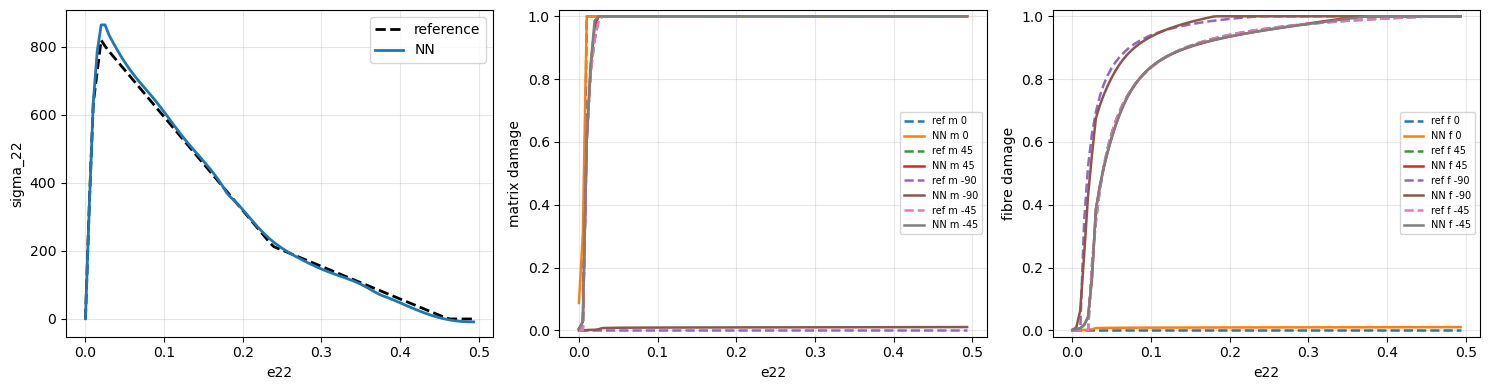

In [10]:
mono_e22 = mono_test_strain_path[:, 1]

if HAVE_MATPLOTLIB:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(mono_e22, mono_stress_ref[:, 1], "k--", lw=2, label="reference")
    axes[0].plot(mono_e22, mono_stress_pred[:, 1], lw=2, label="NN")
    axes[0].set_xlabel("e22")
    axes[0].set_ylabel("sigma_22")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for i, label in enumerate(PLY_LABELS):
        axes[1].plot(mono_e22, mono_damage_ref[:, i], "--", lw=1.8, label=f"ref m {label}")
        axes[1].plot(mono_e22, mono_damage_pred[:, i], lw=1.8, label=f"NN m {label}")
    axes[1].set_xlabel("e22")
    axes[1].set_ylabel("matrix damage")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=7)

    for i, label in enumerate(PLY_LABELS):
        j = i + 4
        axes[2].plot(mono_e22, mono_damage_ref[:, j], "--", lw=1.8, label=f"ref f {label}")
        axes[2].plot(mono_e22, mono_damage_pred[:, j], lw=1.8, label=f"NN f {label}")
    axes[2].set_xlabel("e22")
    axes[2].set_ylabel("fibre damage")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=7)

    fig.tight_layout()
else:
    print("matplotlib is not installed in this Python environment; monotonic arrays were computed.")


## Non-Monotonic Validation

In [11]:
nonmono_stress_pred, nonmono_damage_pred = predict_chained_path(nonmono_test_strain_path, damage_model, stress_model)
print_validation_metrics("non-monotonic", nonmono_stress_pred, nonmono_damage_pred, nonmono_stress_ref, nonmono_damage_ref)


non-monotonic stress RMSE [s11, s22, s33, s12, s23, s13]: [ 128.378995  344.027349 1050.743304    0.012372    0.000108    0.000065]
non-monotonic stress MAE  [s11, s22, s33, s12, s23, s13]: [ 103.211026  266.02276  1041.205718    0.009975    0.000108    0.000062]
non-monotonic damage RMSE:
  matrix_0  : 1.077211e-01
  matrix_45 : 9.179301e-02
  matrix_-90: 5.049398e-03
  matrix_-45: 9.329518e-02
  fibre_0   : 4.969218e-03
  fibre_45  : 1.331630e-01
  fibre_-90 : 7.720851e-02
  fibre_-45 : 1.295166e-01
non-monotonic damage MAE:
  matrix_0  : 1.640030e-02
  matrix_45 : 2.555709e-02
  matrix_-90: 4.894078e-03
  matrix_-45: 2.589423e-02
  fibre_0   : 4.812257e-03
  fibre_45  : 1.253246e-01
  fibre_-90 : 5.241536e-02
  fibre_-45 : 1.217047e-01
non-monotonic final reference stress: [613.057941 558.664019 584.787466   0.         0.         0.      ]
non-monotonic final predicted stress: [ 333.10834  -142.20667  1368.5857      0.017778   -0.000099    0.000083]
non-monotonic final reference dam

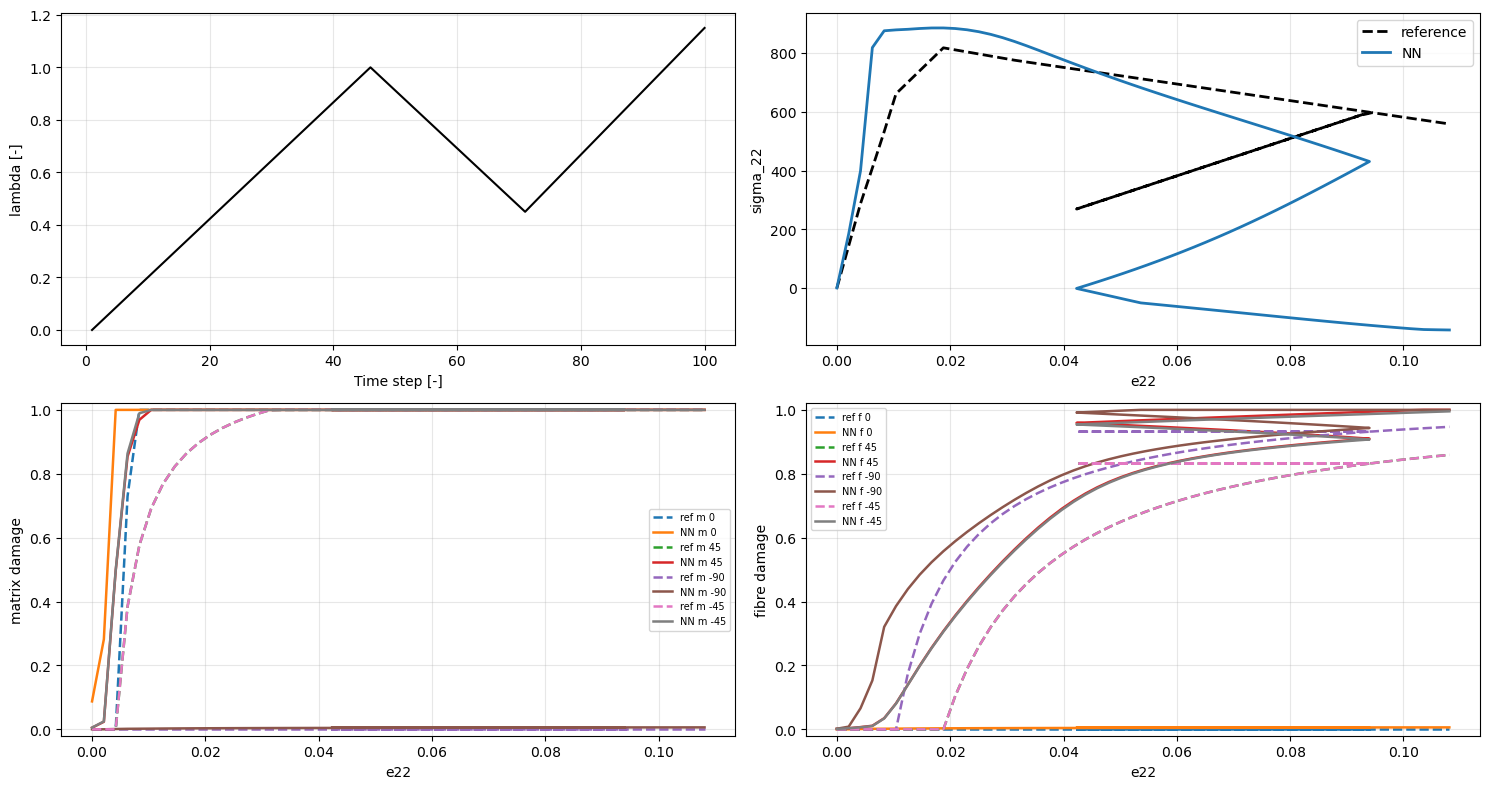

In [12]:
nonmono_e22 = nonmono_test_strain_path[:, 1]
time_step = np.arange(1, nonmono_test_strain_path.shape[0] + 1)

if HAVE_MATPLOTLIB:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.reshape(-1)

    axes[0].plot(time_step, nonmono_lambda, "k-", lw=1.5)
    axes[0].set_xlabel("Time step [-]")
    axes[0].set_ylabel("lambda [-]")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(nonmono_e22, nonmono_stress_ref[:, 1], "k--", lw=2, label="reference")
    axes[1].plot(nonmono_e22, nonmono_stress_pred[:, 1], lw=2, label="NN")
    axes[1].set_xlabel("e22")
    axes[1].set_ylabel("sigma_22")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    for i, label in enumerate(PLY_LABELS):
        axes[2].plot(nonmono_e22, nonmono_damage_ref[:, i], "--", lw=1.8, label=f"ref m {label}")
        axes[2].plot(nonmono_e22, nonmono_damage_pred[:, i], lw=1.8, label=f"NN m {label}")
    axes[2].set_xlabel("e22")
    axes[2].set_ylabel("matrix damage")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=7)

    for i, label in enumerate(PLY_LABELS):
        j = i + 4
        axes[3].plot(nonmono_e22, nonmono_damage_ref[:, j], "--", lw=1.8, label=f"ref f {label}")
        axes[3].plot(nonmono_e22, nonmono_damage_pred[:, j], lw=1.8, label=f"NN f {label}")
    axes[3].set_xlabel("e22")
    axes[3].set_ylabel("fibre damage")
    axes[3].set_ylim(-0.02, 1.02)
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(fontsize=7)

    fig.tight_layout()
else:
    print("matplotlib is not installed in this Python environment; non-monotonic arrays were computed.")
